In [4]:
using Pkg
Pkg.activate("../.")
Pkg.instantiate()

  Activating project at `~/github/FisheriesInsuranceModel`


In [101]:
using Plots, Random,ValueFunctionIterations
include("../src/model.jl"); include("../src/plotting.jl")
function simulate_pars(params,T,st)
    #params = "no_RA_short"
    Nκ = "15"; Nη = "10"; Ns_grid = "24"; Nb_grid = "24"; NΔb_grid = "18"; Nquad = "10"
    include("../parameters/$params.jl")

    ###################################
    ####  Define random variables #####
    ###################################
    X, Xmc = init_ranom_variables(p; Nquad = parse(Int,Nquad))

    # define state variables and check the grid 
    ######################################
    ####  Define state varible grids #####
    ######################################
    # check paramters to get min and max values
    bmax = 0.5; bmin = -3.5; Nb_grid = parse(Int,Nb_grid)
    Δbmax = 1.25; Δbmin = -1.0; NΔb_grid = parse(Int,NΔb_grid)
    if occursin("short", params)
        bmax = 1.0; bmin = -3.0
        Δbmax = 2; Δbmin = -1.25
    elseif occursin("long", params)
        bmax = 0.0; bmin = -4.5
        Δbmax = 0.75; Δbmin = -0.75
    end 

    # savings 
    smax = 2.5; smin = -4.0; Ns_grid = parse(Int,Ns_grid)
    s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
    b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
    Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
    state_grid = [s_grid,b_grid,Δb_grid]
    

    ###############################
    ####  Define action grid  #####
    ###############################
    κmin = 0.01; κmax = 0.99; Nκ = parse(Int,Nκ)
    κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
    ηmin = 0.0; ηmax=0.2; Nη = parse(Int,Nη)
    η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
    action_grid = [κ_grid,η_grid]

    # plot grid
    k=0; u_grid = zeros(2,length(κ_grid)*length(η_grid))
    for (i,j) in Iterators.product(1:length(κ_grid),1:length(η_grid))
        k +=1
        u_grid[:,k] = vcat(κ_grid[i],η_grid[j]) 
    end
    u_grid=u_grid[:,reshape(mapslices(sum,u_grid,dims = 1).<=1,length(κ_grid)*length(η_grid))]


    #######################################
    ####  Strike and index functions  #####
    #######################################
    function strike(s,p)
        return 0.5*(p.b_target +p.b_limit) 
    end

    function index(s,X)
        return exp(s[1])+X[1]
    end 

    ##################################
    ####  Set up dynamic program  ####
    ##################################
    δ = 0.95
    prob, El = init(action_grid,state_grid,δ,p,X,index,strike)
    load_solution(prob,"../results/$params/sol.jld2")

    # stock 
    Random.seed!(1234)
    states, m, f, h, y = simulate_trajectory(p,X,T)
    actions = zeros(2,T)
    for t in 1:T
        s = log(st - p.s̄)
        state = vcat([1.0,s],states[:,t])
        actions[:,t] .= ValueFunctionIterations.ENPV(state, prob.u(state,prob.p), prob.X(state,prob.p), prob.R, prob.F, prob.p, prob.δ, prob.V)[2]
    end 

    # Get variables and derived quantities
    bt = exp.(states[1,:])
    κt = actions[1,:] # consumption
    ηt = actions[2,:] # premium spending
    Elt = broadcast(t->El(states[1,t],states[2,t],states[3,t]),1:(size(states)[2]-1)) # Expected losses 
    η̄t = broadcast(t->price_per_exposure(Elt[t],p.cf,p.cv), 1:(size(states)[2]-1)) # insurance premiums
    Zt= broadcast(t -> index(states[:,t],0.0), 2:size(states)[2]) # index 
    Zct = broadcast(t -> strike(states[:,t],p),1:(size(states)[2]-1)) # claims strike
    wt = broadcast(t -> index_insurance(Zt[t],Zct[t],ηt[t],η̄t[t]), 1:(size(states)[2]-2)) # claims


    return (bt=bt, κt=κt, ηt=ηt, Elt=Elt, η̄t=η̄t, Zt=Zt,  wt=wt, mt=m, yt=y)
end


x = simulate_pars("no_RA_long",5000,-1.0)

(bt = [0.4, 0.3995685980004567, 0.38754726502003073, 0.3750287001202959, 0.38237211179294844, 0.3873176064192575, 0.40255529076486707, 0.44319131891891506, 0.4656581637477718, 0.5514464812455317  …  0.3230502710347504, 0.31401465934250145, 0.32679666690787984, 0.3392946435858809, 0.33719053277415306, 0.3407611255384443, 0.34027448054732584, 0.33344844295931375, 0.3347048509846565, 0.32673888677904395], κt = [0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9899999999999999  …  0.9199999999999999, 0.9199999999999999, 0.57, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999, 0.9199999999999999], ηt = [0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.0

In [102]:
m_change = zeros(length(x.mt)-1)
for i in 2:(length(x.mt)-1)
    m_change[i] = x.mt[i]-x.mt[i-1]
end 

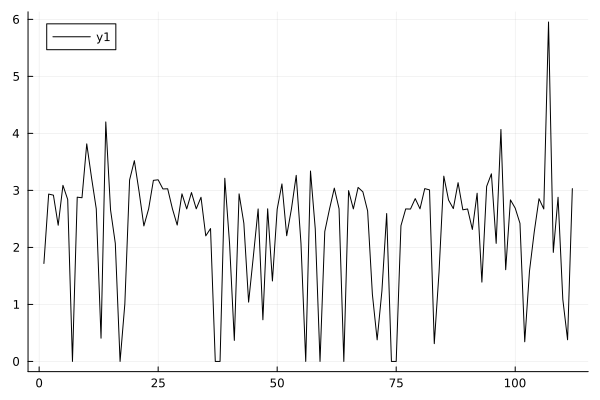

In [103]:
Plots.plot(x.wt[m_change.>0],color="black")

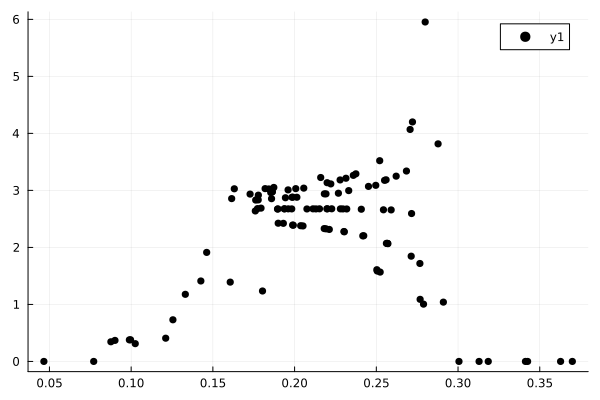

In [107]:
bt = x.bt[2:(end-1)]
Plots.scatter(bt[m_change.>0],x.wt[m_change.>0],color="black")

In [106]:
bt_selected = bt[m_change.>0]
wt_selected = x.wt[m_change.>0]
mean(wt_selected[(bt_selected.>0.15).&&(bt_selected .<0.3)])

2.69578898865002

In [108]:
x_int = simulate_pars("no_RA_intermidiate",5000,-1.0)
m_change = zeros(length(x_int.mt)-1)
for i in 2:(length(x_int.mt)-1)
    m_change[i] = x_int.mt[i]-x_int.mt[i-1]
end 

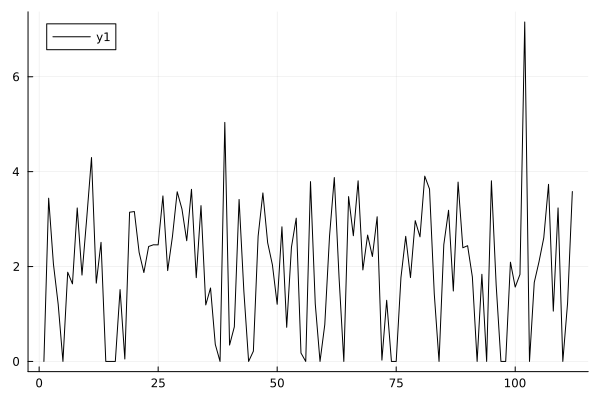

In [109]:
Plots.plot(x_int.wt[m_change.>0],color="black")

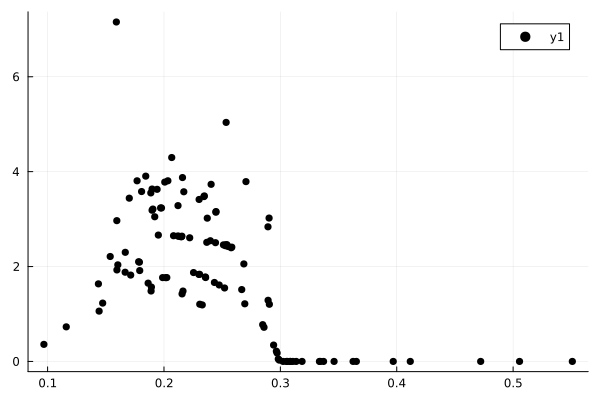

In [110]:
bt = x_int.bt[2:(end-1)]
Plots.scatter(bt[m_change.>0],x_int.wt[m_change.>0],color="black")

In [112]:
bt_selected = bt[m_change.>0]
wt_selected = x_int.wt[m_change.>0]
mean(wt_selected[(bt_selected.>0.15).&&(bt_selected .<0.3)])

2.444405213715812

In [122]:
x_RA = simulate_pars("RA_long",5000,-1.0)
m_change = zeros(length(x_RA.mt)-1)
for i in 2:(length(x_RA.mt)-1)
    m_change[i] = x_RA.mt[i]-x_RA.mt[i-1]
end 

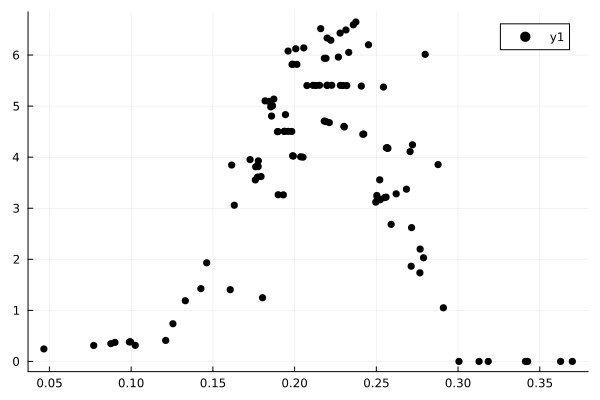

In [123]:
bt = x_RA.bt[2:(end-1)]
Plots.scatter(bt[m_change.>0],x_RA.wt[m_change.>0],color="black")

In [124]:
x_RA_int = simulate_pars("RA_intermidiate",5000,-1.0)
m_change_int = zeros(length(x_RA_int.mt)-1)
for i in 2:(length(x_RA_int.mt)-1)
    m_change_int[i] = x_RA_int.mt[i]-x_RA_int.mt[i-1]
end 

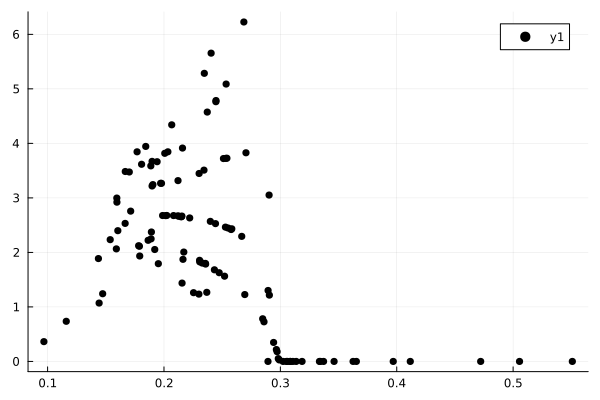

In [125]:
bt = x_RA_int.bt[2:(end-1)]
Plots.scatter(bt[m_change_int.>0],x_RA_int.wt[m_change_int.>0],color="black")

In [126]:
x_RA_short = simulate_pars("RA_short",5000,-1.0)
m_change_short = zeros(length(x_RA_short.mt)-1)
for i in 2:(length(x_RA_short.mt)-1)
    m_change_short[i] = x_RA_short.mt[i]-x_RA_short.mt[i-1]
end 

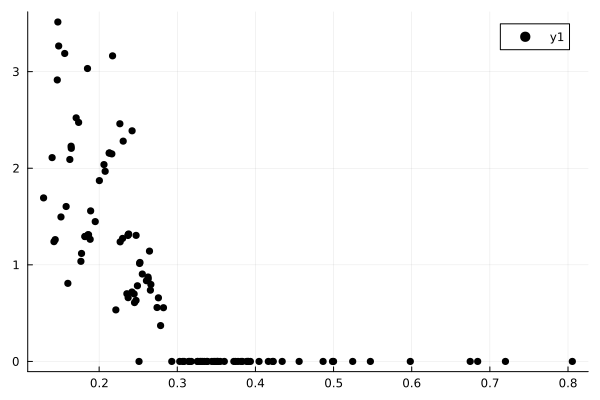

In [127]:
bt = x_RA_short.bt[2:(end-1)]
Plots.scatter(bt[m_change_short.>0],x_RA_short.wt[m_change_short.>0],color="black")